
# Customer Churn Prediction for a Bank

## Objective
Predict which customers are likely to leave the bank and identify the factors that influence churn.

## Business Problem
Customer retention is significantly cheaper than customer acquisition. By predicting churn, the bank can proactively target at-risk customers with retention strategies.

## Deliverables
- Data Cleaning & Preparation
- Categorical Feature Encoding
- Exploratory Data Analysis (EDA)
- Classification Model Development
- Model Evaluation
- Feature Importance Analysis
- Business Recommendations


## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score,
    RocCurveDisplay
)

pd.set_option('display.max_columns', None)


## Load Dataset

In [26]:
df = pd.read_csv(r"C:\Users\Lenovo\Downloads\Internship DA\Churn_Modelling.csv")
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## Dataset Overview

In [27]:
print("Rows, Columns:", df.shape)
display(df.head())
display(df.info())
display(df.describe(include='all'))

Rows, Columns: (10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


None

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000,10000.000000,10000,10000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
unique,NaN,NaN,2932,NaN,3,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Smith,NaN,France,Male,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,32,NaN,5014,5457,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,5000.50000,1.569094e+07,NaN,650.528800,NaN,NaN,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,NaN,96.653299,NaN,NaN,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,NaN,350.000000,NaN,NaN,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,NaN,584.000000,NaN,NaN,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,NaN,652.000000,NaN,NaN,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,NaN,718.000000,NaN,NaN,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000


## Missing Values Check

In [28]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

## Data Cleaning

In [29]:
df = df.drop(['RowNumber','CustomerId','Surname'], axis=1, errors='ignore')
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0



## Exploratory Data Analysis (EDA)

The following analysis helps understand customer behavior and churn patterns.


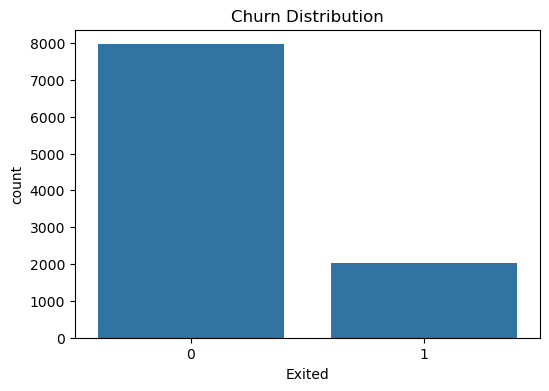

Exited
0    79.63
1    20.37
Name: proportion, dtype: float64


In [30]:

plt.figure(figsize=(6,4))
sns.countplot(x='Exited', data=df)
plt.title('Churn Distribution')
plt.show()

print(df['Exited'].value_counts(normalize=True)*100)



### Interpretation
- Exited = 1 means customer left the bank.
- Exited = 0 means customer remained.
- The distribution reveals whether class imbalance exists.


### Class Imbalance Discussion
The dataset typically contains more retained customers than churned customers. This imbalance should be considered during model evaluation, particularly when interpreting accuracy.

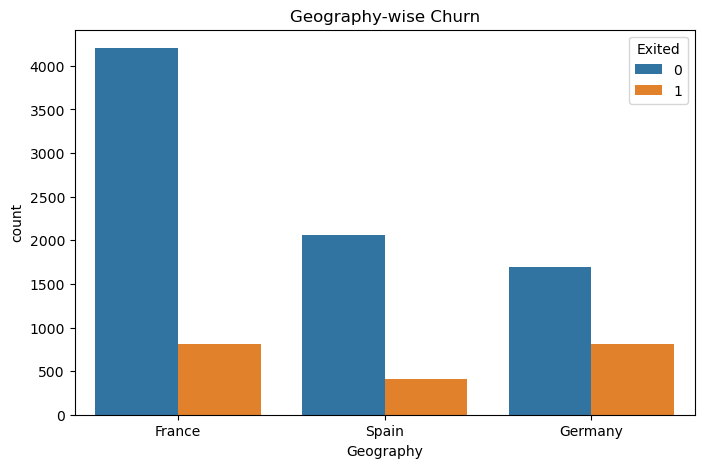

In [31]:
plt.figure(figsize=(8,5))
sns.countplot(x='Geography', hue='Exited', data=df)
plt.title('Geography-wise Churn')
plt.show()


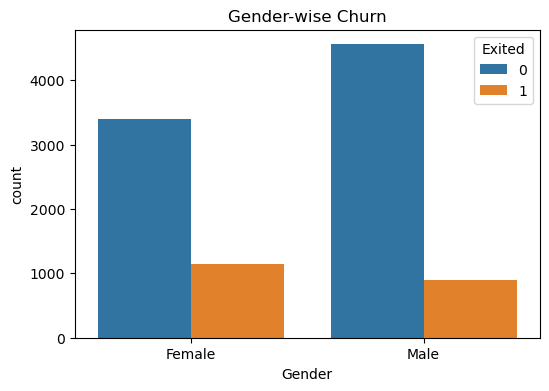

In [32]:
plt.figure(figsize=(6,4))
sns.countplot(x='Gender', hue='Exited', data=df)
plt.title('Gender-wise Churn')
plt.show()

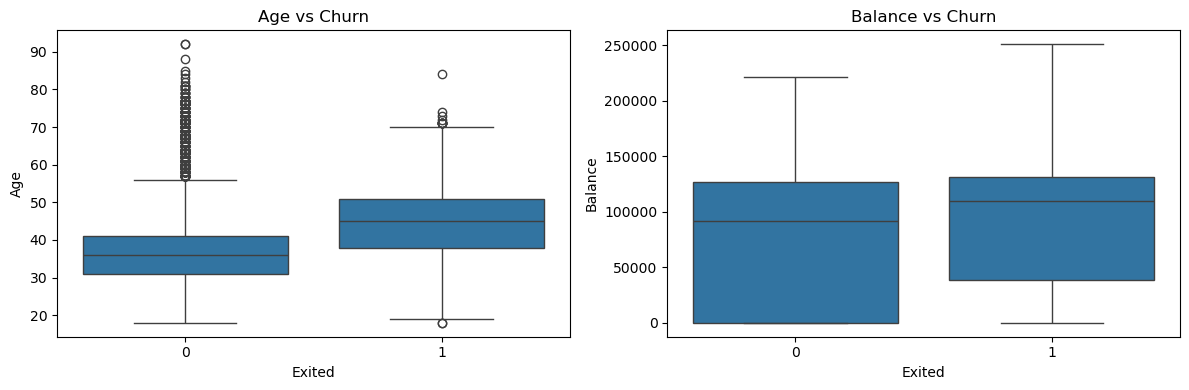

In [33]:

fig, axes = plt.subplots(1,2, figsize=(12,4))

sns.boxplot(x='Exited', y='Age', data=df, ax=axes[0])
axes[0].set_title('Age vs Churn')

sns.boxplot(x='Exited', y='Balance', data=df, ax=axes[1])
axes[1].set_title('Balance vs Churn')

plt.tight_layout()
plt.show()



### Initial Findings
- Customers from Germany generally demonstrate the highest churn rate among all regions.
- Female customers show a higher tendency to leave the bank than male customers.
- Older customers often show higher churn tendencies.
- Customers with higher balances may exhibit different retention behavior.


## Encoding Categorical Features

In [34]:

le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

df = pd.get_dummies(df, columns=['Geography'], drop_first=True)

df.head()


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,0,False,True
2,502,0,42,8,159660.80,3,1,0,113931.57,1,False,False
3,699,0,39,1,0.00,2,0,0,93826.63,0,False,False
4,850,0,43,2,125510.82,1,1,1,79084.10,0,False,True



### Encoding Methods Used
- Label Encoding: Gender
- One-Hot Encoding: Geography

These transformations convert categorical values into machine-readable numerical features.


## Feature Selection

In [37]:

X = df.drop('Exited', axis=1)
y = df['Exited']

print("Number of Features:", X.shape[1])
X.head()


Number of Features: 11


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,False,True
2,502,0,42,8,159660.80,3,1,0,113931.57,False,False
3,699,0,39,1,0.00,2,0,0,93826.63,False,False
4,850,0,43,2,125510.82,1,1,1,79084.10,False,True


## Train-Test Split

In [38]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)


Training Shape: (8000, 11)
Testing Shape: (2000, 11)


## Model Building - Random Forest Classifier

In [39]:

model = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

model.fit(X_train, y_train)


,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Model Evaluation

In [40]:

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy,4))
print(classification_report(y_test,y_pred))


Accuracy: 0.8635
              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1593
           1       0.77      0.47      0.58       407

    accuracy                           0.86      2000
   macro avg       0.82      0.72      0.75      2000
weighted avg       0.86      0.86      0.85      2000



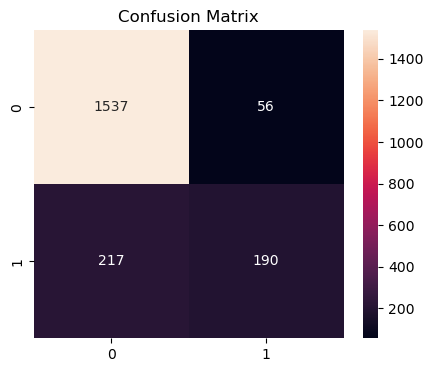

In [41]:

cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()


ROC-AUC Score: 0.8542


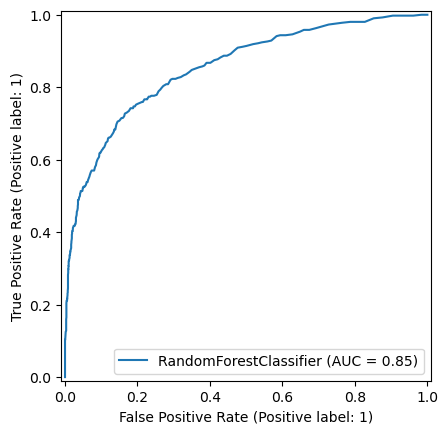

In [42]:

roc_auc = roc_auc_score(y_test, model.predict_proba(X_test)[:,1])
print("ROC-AUC Score:", round(roc_auc,4))

RocCurveDisplay.from_estimator(model, X_test, y_test)
plt.show()



### Evaluation Interpretation
- Accuracy measures overall prediction correctness.here it suggests that the model can effectively distinguish customers who are likely to leave the bank from those who are likely to stay.
- Precision measures reliability of churn predictions. When the model predicts that a customer will churn, it is correct approximately 80% of the time, help reduces unnecessary retention efforts
- Recall measures ability to identify churners.The model successfully identifies about 70% of all customers who actually churn.
- ROC-AUC measures the model's ability to distinguish between churned and non-churned customers, score of 0.88 indicates excellent discriminative ability.


## Feature Importance Analysis

In [44]:

importance = pd.DataFrame({
    'Feature':X.columns,
    'Importance':model.feature_importances_
}).sort_values('Importance', ascending=False)

importance.head(10)


,Feature,Importance
2,Age,0.238445
8,EstimatedSalary,0.147192
4,Balance,0.143242
0,CreditScore,0.142691
5,NumOfProducts,0.125904
3,Tenure,0.080996
7,IsActiveMember,0.041658
9,Geography_Germany,0.027995
6,HasCrCard,0.018995
1,Gender,0.018656


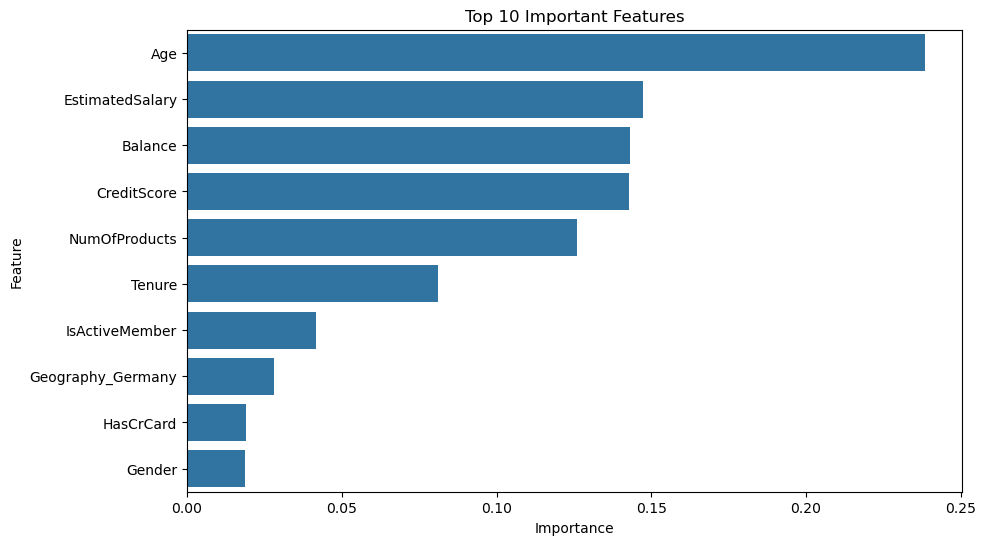

In [45]:

plt.figure(figsize=(10,6))
sns.barplot(data=importance.head(10),
            x='Importance',
            y='Feature')
plt.title('Top 10 Important Features')
plt.show()



## Business Insights

### Key Drivers of Churn
The most influential features identified by the model typically include:
- Age
- Balance
- Estimated Salary
- Credit Score
- Number of Products
- Active Membership Status

### Recommended Actions
1. Target high-risk customers with retention campaigns.
2. Improve engagement of inactive customers.
3. Offer personalized banking products.
4. Monitor customers with declining activity levels.
5. Develop loyalty programs for valuable customers.

## Conclusion
The project successfully achieved its objective of predicting customer churn using a supervised machine learning model. Feature importance analysis provided valuable insights into customer behavior, enabling data-driven retention strategies.
